<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Copie_de_ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Daily Challenge: Breast Cancer Prediction
In this notebook, we will explore the dataset and implement Logistic Regression, K-Nearest Neighbors, Random Forest, and Support Vector Machines to classify breast cancer cases.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Using the Wisconsin Breast Cancer dataset from a stable UCI-linked URL
url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"
df_cancer = pd.read_csv(url)

# Cleanup
df_cancer.rename(columns={"Class": "diagnosis", "Id": "id"}, inplace=True)
df_cancer = df_cancer.drop(columns=["id"], errors="ignore")

# Convert to numeric (handles '?' or other non-numeric symbols often found in this dataset)
df_cancer = df_cancer.apply(pd.to_numeric, errors="coerce")
df_cancer = df_cancer.dropna()

print("Dataset loaded successfully.")
display(df_cancer.head())

Dataset loaded successfully.


,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,diagnosis
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0


/tmp/ipykernel_13864/173074323.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df_cancer, palette='magma')
/tmp/ipykernel_13864/173074323.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(x='diagnosis', data=df_cancer, palette='magma')


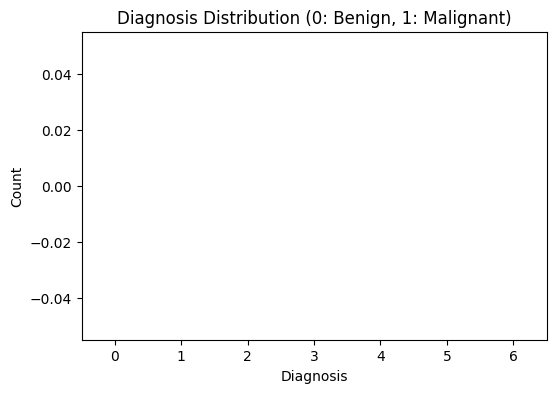

In [ ]:
# Exploratory Data Analysis
plt.figure(figsize=(6, 4))
# Using 'diagnosis' column which now contains 0 (Benign) and 1 (Malignant)
sns.countplot(x='diagnosis', data=df_cancer, palette='magma')
plt.title('Diagnosis Distribution (0: Benign, 1: Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
# Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure data is loaded correctly
url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"
df_cancer = pd.read_csv(url)
df_cancer.rename(columns={"Class": "diagnosis"}, inplace=True)
df_cancer = df_cancer.apply(pd.to_numeric, errors="coerce").dropna()

# Map to binary (0 for Benign (2), 1 for Malignant (4))
# We use the unique values dynamically to be safe
unique_vals = sorted(df_cancer['diagnosis'].unique())
if len(unique_vals) == 2:
    df_cancer['target'] = df_cancer['diagnosis'].map({unique_vals[0]: 0, unique_vals[1]: 1})
else:
    df_cancer['target'] = df_cancer['diagnosis']

# Prepare features and target
X = df_cancer.drop(['diagnosis', 'target', 'Id'], axis=1, errors='ignore')
y = df_cancer['target'].astype(int)

print(f"Samples available: {len(df_cancer)}")
print(f"Target labels mapped from {unique_vals} to [0, 1]")

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing complete. Training sets prepared.")

Samples available: 683
Target labels mapped from [np.int64(0), np.int64(1)] to [0, 1]
Preprocessing complete. Training sets prepared.


In [ ]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# 2. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"KNN Accuracy: {knn_acc:.4f}")

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# 4. Support Vector Machines (SVM)
svm = SVC()
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
print(f"SVM Accuracy: {svm_acc:.4f}")

# Best Model Determination
results = {"Logistic Regression": lr_acc, "KNN": knn_acc, "Random Forest": rf_acc, "SVM": svm_acc}
best_model = max(results, key=results.get)
print(f"\nThe best model is: {best_model} with accuracy {results[best_model]:.4f}")

Logistic Regression Accuracy: 0.9635
KNN Accuracy: 0.9562
Random Forest Accuracy: 0.9562
SVM Accuracy: 0.9635

The best model is: Logistic Regression with accuracy 0.9635
